In [1]:
import numpy as np
import tensorflow.keras as keras
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
IMAGE_DIMENSIONS = (x_train.shape[1], x_train.shape[2], x_train.shape[3])
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [3]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from keras.models import Sequential

In [4]:
def plot_curves(history, model_name):
    def plot_loss_curves(history, plot):
        plot.plot(history.history['loss'], label='Train Loss')
        plot.plot(history.history['val_loss'], label='Validation Loss')
        plot.title(f'{model_name}: Training & Validation Loss')
        plot.xlabel('Epoch')
        plot.ylabel('Mean Squared Error (Loss)')
        plot.legend()
        plot.grid(True)

    def plot_accuracy_curves(history, plot):
        plot.plot(history.history['accuracy'], label='Train Accuracy')
        plot.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plot.title(f'{model_name}: Training & Validation Accuracy')
        plot.xlabel('Epoch')
        plot.ylabel('Accuracy')
        plot.legend()
        plot.grid(True)
    
    plt.figure(figsize=(5,5))
    plot_loss_curves(history, plt)
    plt.show()
    plt.figure(figsize=(5,5))
    plot_accuracy_curves(history, plt)
    plt.show()

## Basic CNN

In [5]:
basic_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    # The convolution layer detects specific features of an image in every section of the image
    Conv2D(32, 3, padding='same', activation='relu'),
    # Pooling reduces the dimensions of the feature maps from the convolution layer
    MaxPooling2D((2,2)),

    # The number of filters (the first parameter of Conv2D) expand to account for different combinations 
    # of features in the deeper parts of the model
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation = 'softmax') # Last dense layer has 10 units for the 10 types of labels
])

In [6]:
basic_cnn_model.compile(
    optimizer='adam',
    # Sparse categorical crossentropy is used when multiple labels are provided as 
    # integers, but not one-hot encoded
    loss = 'sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
basic_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# This cell will take about a few minutes to run. If you have more layers or epochs, it could run longer
history_basic_cnn = basic_cnn_model.fit(
    x_train,
    y_train,
    epochs = 10,
    validation_split = 0.1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.4535 - loss: 1.8045 - val_accuracy: 0.5500 - val_loss: 1.2833
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.5825 - loss: 1.1794 - val_accuracy: 0.6032 - val_loss: 1.1453
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.6357 - loss: 1.0409 - val_accuracy: 0.6428 - val_loss: 1.0307
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.6758 - loss: 0.9289 - val_accuracy: 0.6396 - val_loss: 1.0526
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.7032 - loss: 0.8433 - val_accuracy: 0.6760 - val_loss: 1.0018
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.7349 - loss: 0.7612 - val_accuracy: 0.6762 - val_loss: 1.0208
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.7526 - loss: 0.7061 - val_accuracy: 0.6424 - val_loss: 1.1212
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7790 -

In [8]:
basic_train_loss = history_basic_cnn.history['loss']
basic_train_accuracy = history_basic_cnn.history['accuracy']
basic_validation_loss = history_basic_cnn.history['val_loss']
basic_validation_accuracy = history_basic_cnn.history['val_accuracy']
basic_test_loss, basic_test_accuracy = basic_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6663 - loss: 1.2212


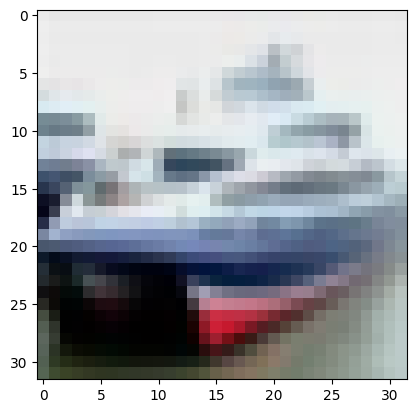

In [9]:
plt.imshow(x_test[1])

In [10]:
basic_cnn_predictions = basic_cnn_model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [11]:
print(f"Basic CNN Model")
print(f"Final Train Accuracy: {basic_train_accuracy[len(basic_train_accuracy)-1]:.3f}, Final Train Loss: {basic_train_loss[len(basic_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {basic_validation_accuracy[len(basic_validation_accuracy)-1]:.3f}, Final Validation Loss: {basic_validation_loss[len(basic_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {basic_test_accuracy:.3f}, Test Loss: {basic_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(basic_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

Basic CNN Model
Final Train Accuracy: 0.819, Final Train Loss: 0.518
Final Validation Accuracy: 0.667, Final Validation Loss: 1.197
Test Accuracy: 0.666, Test Loss: 1.221
Example Prediction: ship, Actual = ship


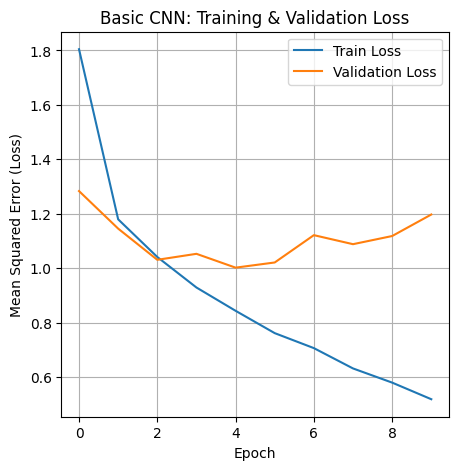

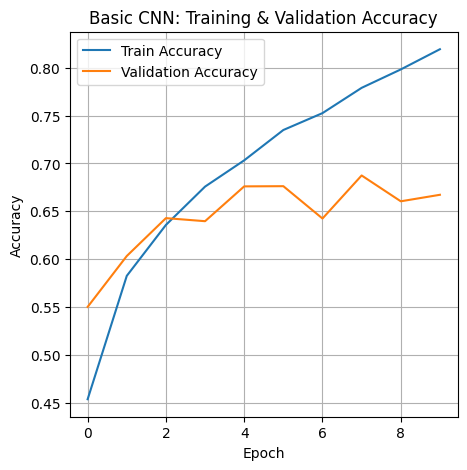

In [12]:
plot_curves(history_basic_cnn, "Basic CNN")
# Ideally, the train and validation curves should converge smoothly. The validation curve here is unstable and crosses the train curve, 
# meaning the model is unstable and likely overfitting.

## CNN with More Layers

In [13]:
more_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(256, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation = 'softmax')
])

In [14]:
more_cnn_model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
more_cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 653,386 (2.49 MB)

 Trainable params: 653,386 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history_more_cnn = more_cnn_model.fit(
    x_train,
    y_train,
    epochs = 10,
    validation_split = 0.1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 18ms/step - accuracy: 0.4710 - loss: 1.5672 - val_accuracy: 0.5684 - val_loss: 1.1958
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.6006 - loss: 1.1282 - val_accuracy: 0.6162 - val_loss: 1.0793
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.6556 - loss: 0.9828 - val_accuracy: 0.6718 - val_loss: 0.9387
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.6964 - loss: 0.8716 - val_accuracy: 0.6756 - val_loss: 0.9200
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.7262 - loss: 0.7818 - val_accuracy: 0.7032 - val_loss: 0.8756
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.7487 - loss: 0.7164 - val_accuracy: 0.7012 - val_loss: 0.8949
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.7720 - loss: 0.6610 - val_accuracy: 0.6950 - val_loss: 0.9510
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.7921 -

In [16]:
more_train_loss = history_more_cnn.history['loss']
more_train_accuracy = history_more_cnn.history['accuracy']
more_validation_loss = history_more_cnn.history['val_loss']
more_validation_accuracy = history_more_cnn.history['val_accuracy']
more_test_loss, more_test_accuracy = more_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6696 - loss: 1.1530


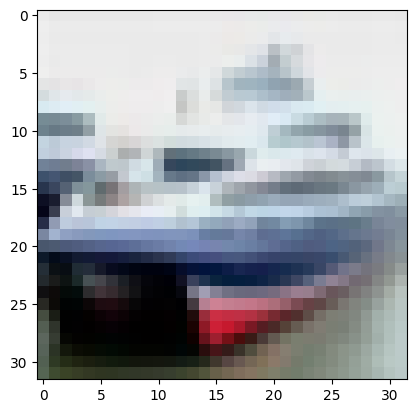

In [17]:
plt.imshow(x_test[1])

In [18]:
more_cnn_predictions = more_cnn_model.predict(x_test)
print(f"CNN Model with More Layers")
print(f"Final Train Accuracy: {more_train_accuracy[len(more_train_accuracy)-1]:.3f}, Final Train Loss: {more_train_loss[len(more_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {more_validation_accuracy[len(more_validation_accuracy)-1]:.3f}, Final Validation Loss: {more_validation_loss[len(more_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {more_test_accuracy:.3f}, Test Loss: {more_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(more_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
CNN Model with More Layers
Final Train Accuracy: 0.827, Final Train Loss: 0.500
Final Validation Accuracy: 0.681, Final Validation Loss: 1.102
Test Accuracy: 0.670, Test Loss: 1.153
Example Prediction: ship, Actual = ship


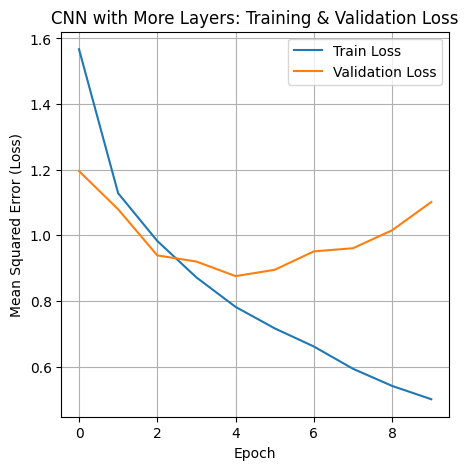

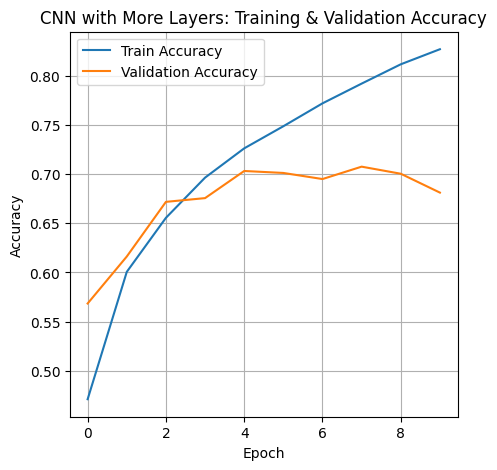

In [19]:
plot_curves(history_more_cnn, "CNN with More Layers")
# The curves here are even more unstable than the basic CNN. The results are also worse, so adding more layers isn't better here.

## CNN with More Epochs

In [20]:
epoch_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation = 'softmax')
])

In [21]:
epoch_cnn_model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
epoch_cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_epoch_cnn = epoch_cnn_model.fit(
    x_train,
    y_train,
    epochs = 20,
    validation_split = 0.1
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.4675 - loss: 1.8003 - val_accuracy: 0.5524 - val_loss: 1.2519
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.5947 - loss: 1.1460 - val_accuracy: 0.6250 - val_loss: 1.0771
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.6444 - loss: 1.0108 - val_accuracy: 0.6410 - val_loss: 1.0148
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.6785 - loss: 0.9113 - val_accuracy: 0.6564 - val_loss: 1.0268
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7123 - loss: 0.8192 - val_accuracy: 0.6726 - val_loss: 0.9429
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.7421 - loss: 0.7375 - val_accuracy: 0.6748 - val_loss: 1.0059
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.7685 - loss: 0.6590 - val_accuracy: 0.6868 - val_loss: 0.9981
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.7920 -

In [23]:
epoch_train_loss = history_epoch_cnn.history['loss']
epoch_train_accuracy = history_epoch_cnn.history['accuracy']
epoch_validation_loss = history_epoch_cnn.history['val_loss']
epoch_validation_accuracy = history_epoch_cnn.history['val_accuracy']
epoch_test_loss, epoch_test_accuracy = epoch_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6484 - loss: 2.1375


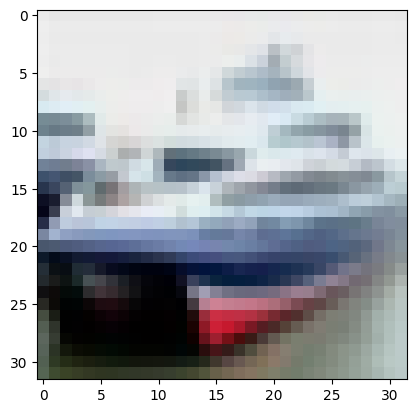

In [24]:
plt.imshow(x_test[1])

In [25]:
epoch_cnn_predictions = epoch_cnn_model.predict(x_test)
print(f"CNN Model with More Epochs")
print(f"Final Train Accuracy: {epoch_train_accuracy[len(epoch_train_accuracy)-1]:.3f}, Final Train Loss: {epoch_train_loss[len(epoch_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {epoch_validation_accuracy[len(epoch_validation_accuracy)-1]:.3f}, Final Validation Loss: {epoch_validation_loss[len(epoch_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {epoch_test_accuracy:.3f}, Test Loss: {epoch_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(epoch_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
CNN Model with More Epochs
Final Train Accuracy: 0.907, Final Train Loss: 0.289
Final Validation Accuracy: 0.661, Final Validation Loss: 1.982
Test Accuracy: 0.648, Test Loss: 2.137
Example Prediction: automobile, Actual = ship


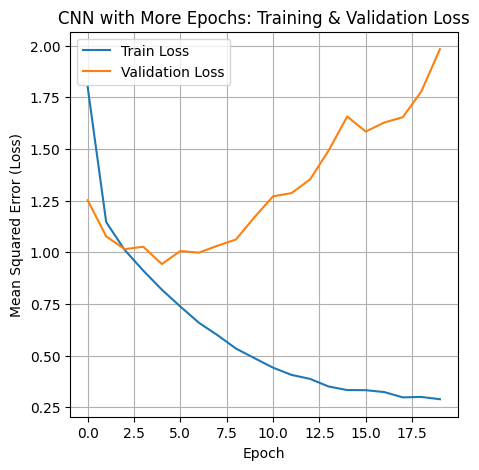

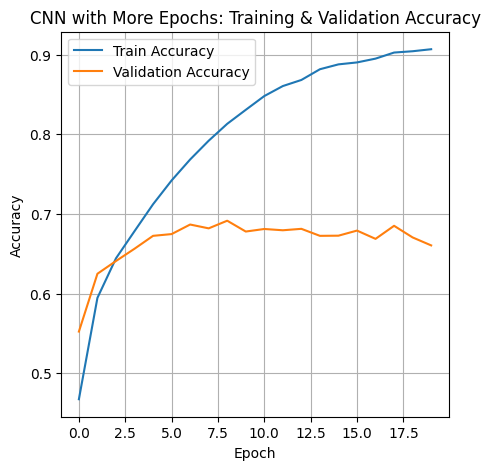

In [26]:
plot_curves(history_epoch_cnn, "CNN with More Epochs")
# While the resulting accuracies are much better than the basic model, the curves are very unstable 
# and the test accuracy is similar to the basic model. So that means 20 epochs could be too many.

## CNN with Dropout

In [27]:
dropout_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation = 'softmax')
])

In [28]:
dropout_cnn_model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
dropout_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_dropout_cnn = dropout_cnn_model.fit(
    x_train,
    y_train,
    epochs = 10,
    validation_split = 0.1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.4067 - loss: 1.8118 - val_accuracy: 0.5726 - val_loss: 1.2108
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.5444 - loss: 1.3059 - val_accuracy: 0.6016 - val_loss: 1.1384
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.5851 - loss: 1.1914 - val_accuracy: 0.6136 - val_loss: 1.1036
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.6120 - loss: 1.1171 - val_accuracy: 0.6430 - val_loss: 1.0292
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.6297 - loss: 1.0674 - val_accuracy: 0.6598 - val_loss: 1.0031
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.6485 - loss: 1.0171 - val_accuracy: 0.6804 - val_loss: 0.9360
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.6680 - loss: 0.9708 - val_accuracy: 0.6718 - val_loss: 0.9705
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.6788 -

In [30]:
dropout_train_loss = history_dropout_cnn.history['loss']
dropout_train_accuracy = history_dropout_cnn.history['accuracy']
dropout_validation_loss = history_dropout_cnn.history['val_loss']
dropout_validation_accuracy = history_dropout_cnn.history['val_accuracy']
dropout_test_loss, dropout_test_accuracy = dropout_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6728 - loss: 0.9994


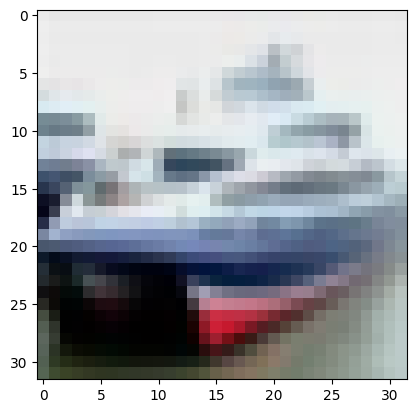

In [31]:
plt.imshow(x_test[1])

In [32]:
dropout_cnn_predictions = dropout_cnn_model.predict(x_test)
print(f"CNN Model with Dropout")
print(f"Final Train Accuracy: {dropout_train_accuracy[len(dropout_train_accuracy)-1]:.3f}, Final Train Loss: {dropout_train_loss[len(dropout_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {dropout_validation_accuracy[len(dropout_validation_accuracy)-1]:.3f}, Final Validation Loss: {dropout_validation_loss[len(dropout_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {dropout_test_accuracy:.3f}, Test Loss: {dropout_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(dropout_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
CNN Model with Dropout
Final Train Accuracy: 0.699, Final Train Loss: 0.874
Final Validation Accuracy: 0.698, Final Validation Loss: 0.934
Test Accuracy: 0.673, Test Loss: 0.999
Example Prediction: ship, Actual = ship


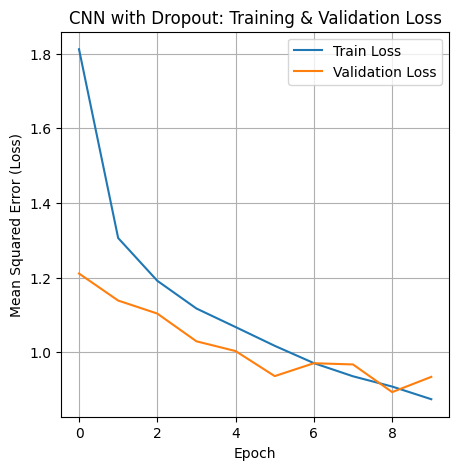

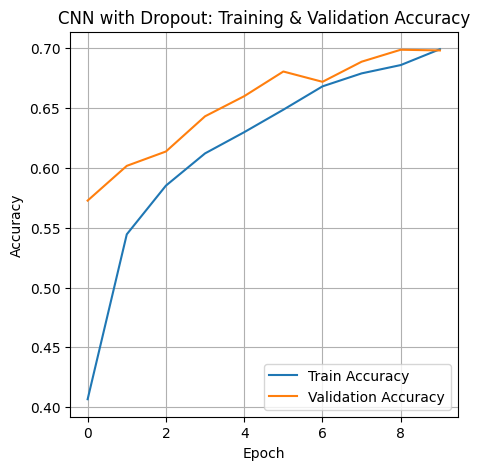

In [33]:
plot_curves(history_dropout_cnn, "CNN with Dropout")
# While the results are about the same as the basic model, the curves are more stable.
# Adding more dropout layers, perhaps between the convolution and pooling layers could help.
# Doing this with more epochs could yield some better results.